In [1]:
from pathlib import Path
import pandas as pd

table_pkl_dim2 = Path("~/t7ssd/classification_results/dim2/subsample_results_table.pkl")
df = pd.read_pickle(table_pkl_dim2)

In [2]:
group_cols = [
    "dimension",
    "sampling_strategy",
    "sample_size_per_dim",
    "n_instances_train",
    "n_runs_train",
    "n_feval_train",
]

# aggregate over the 5 folds
fold_agg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        acc_mean=("accuracy_median", "mean"),
        acc_sd=("accuracy_median", "std"),
        acc_allruns_mean=("accuracy_allruns", "mean"),
        consistency_mean=("consistency", "mean"),
        cv_instance_median_mean=("cv_instance_median_mean", "first"),
        cv_instance_median_median=("cv_instance_median_median", "first"),
        cv_function_median_mean=("cv_function_median_mean", "first"),
        cv_function_median_median=("cv_function_median_median", "first"),
        # feature meta‑info (optional)
        # n_features=("n_features", "first"),
        # n_omitted_features=("n_omitted_features", "first"),
        # omitted_features=("omitted_features", "first"),
    )
)

In [3]:
df.columns


Index(['dimension', 'sampling_strategy', 'sample_size_per_dim',
       'n_instances_train', 'n_runs_train', 'n_feval_train', 'fold',
       'n_features', 'n_omitted_features', 'omitted_features',
       'cv_instance_median_mean', 'cv_instance_median_median',
       'cv_function_median_mean', 'cv_function_median_median',
       'cv_training_folds_median_mean', 'cv_training_folds_median_median',
       'accuracy_median', 'accuracy_allruns', 'consistency'],
      dtype='str')

In [4]:
pd.qcut(df["n_feval_train"], q=4).value_counts()

n_feval_train
(1199.999, 14400.0]    1080
(14400.0, 36000.0]     1020
(77700.0, 480000.0]     960
(36000.0, 77700.0]      780
Name: count, dtype: int64

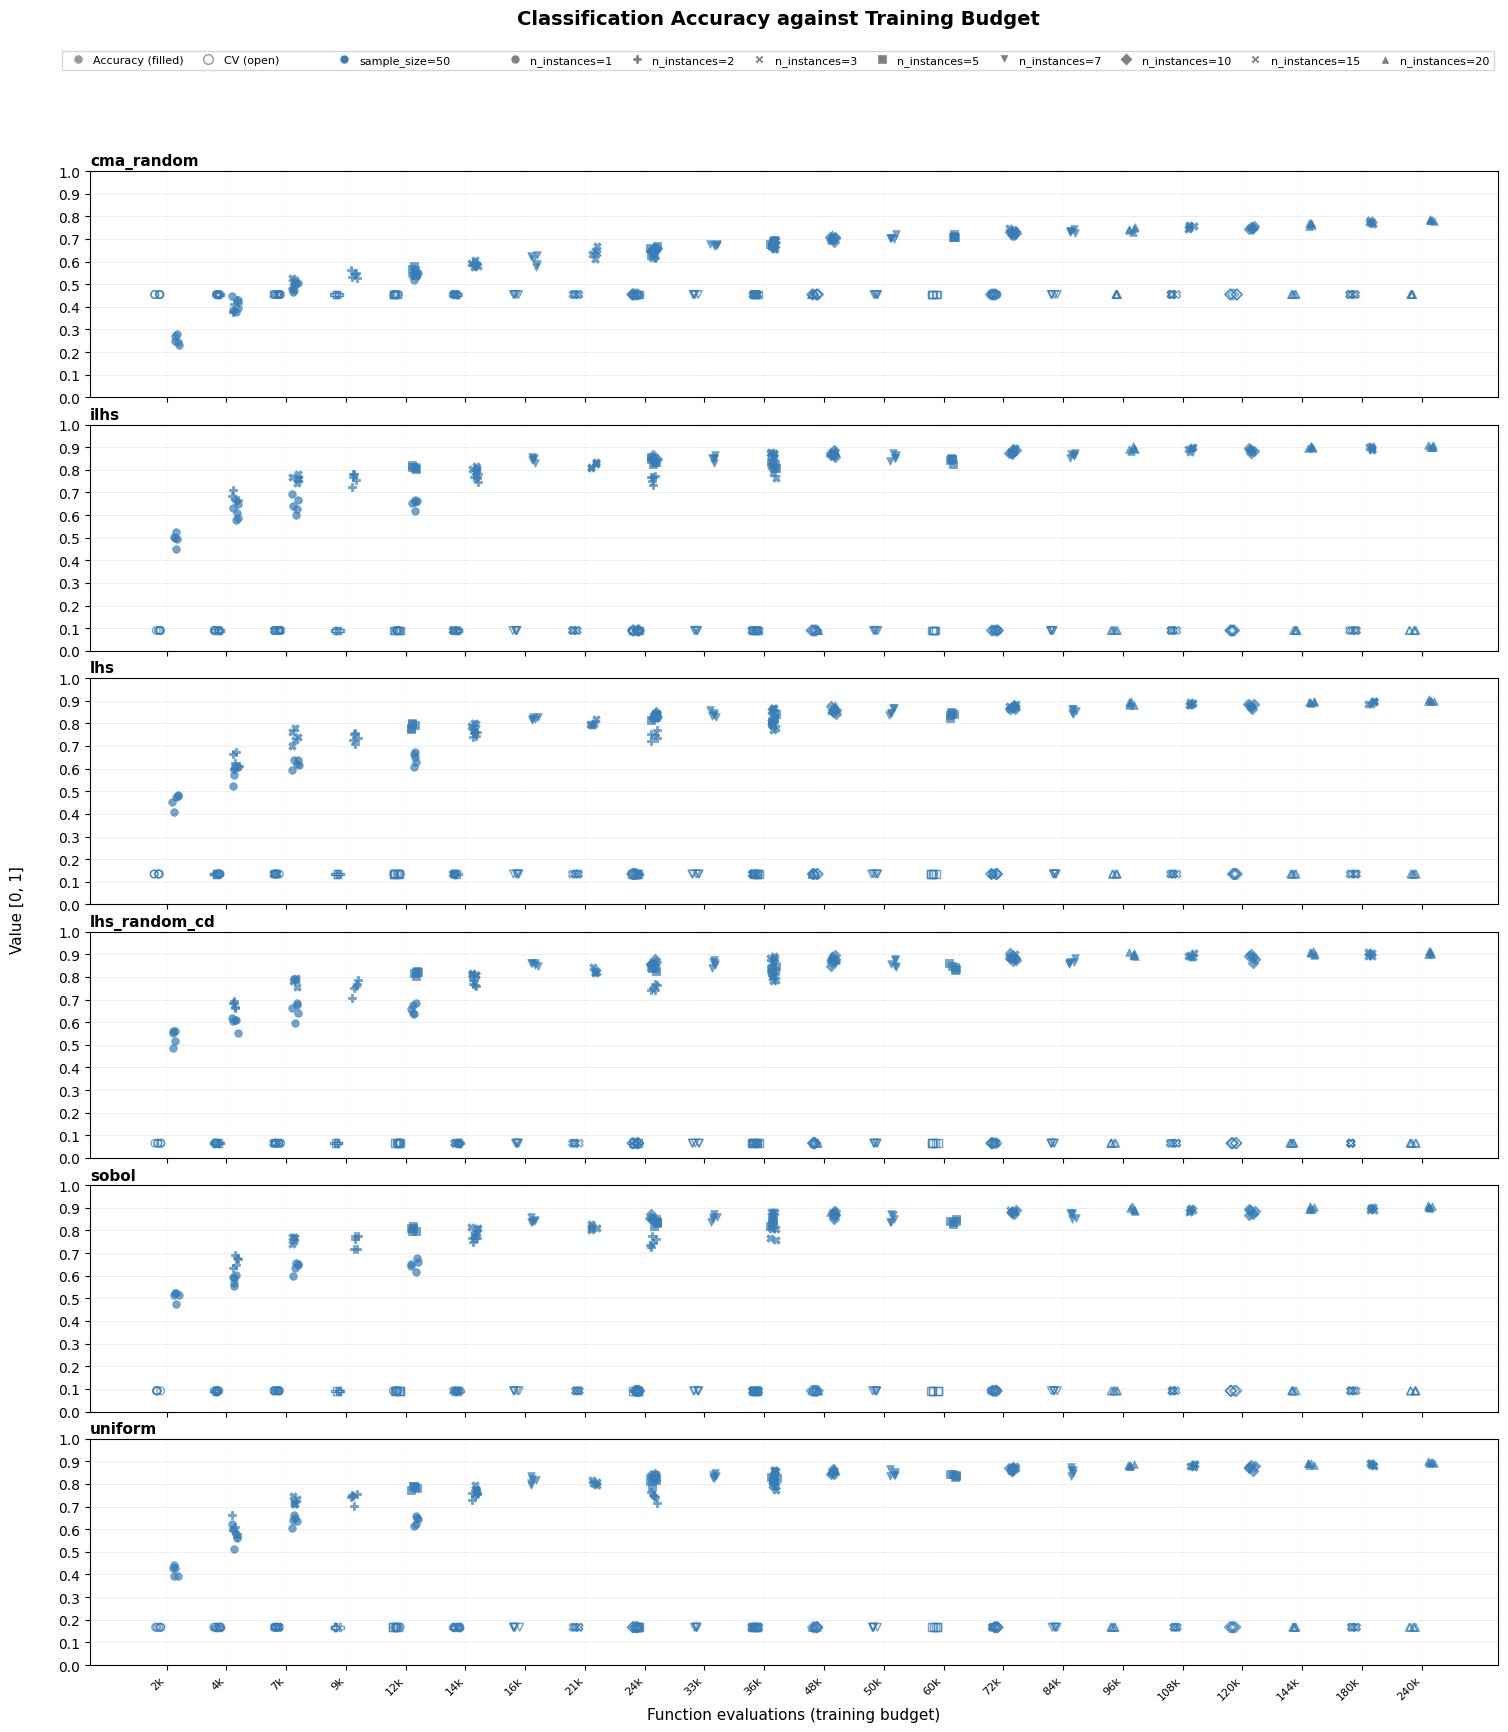

(<Figure size 1600x1800 with 6 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'lhs_random_cd'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [5]:
from ela_table_helper import *
plot_cv_vs_accuracy(df[df.sample_size_per_dim == 50])


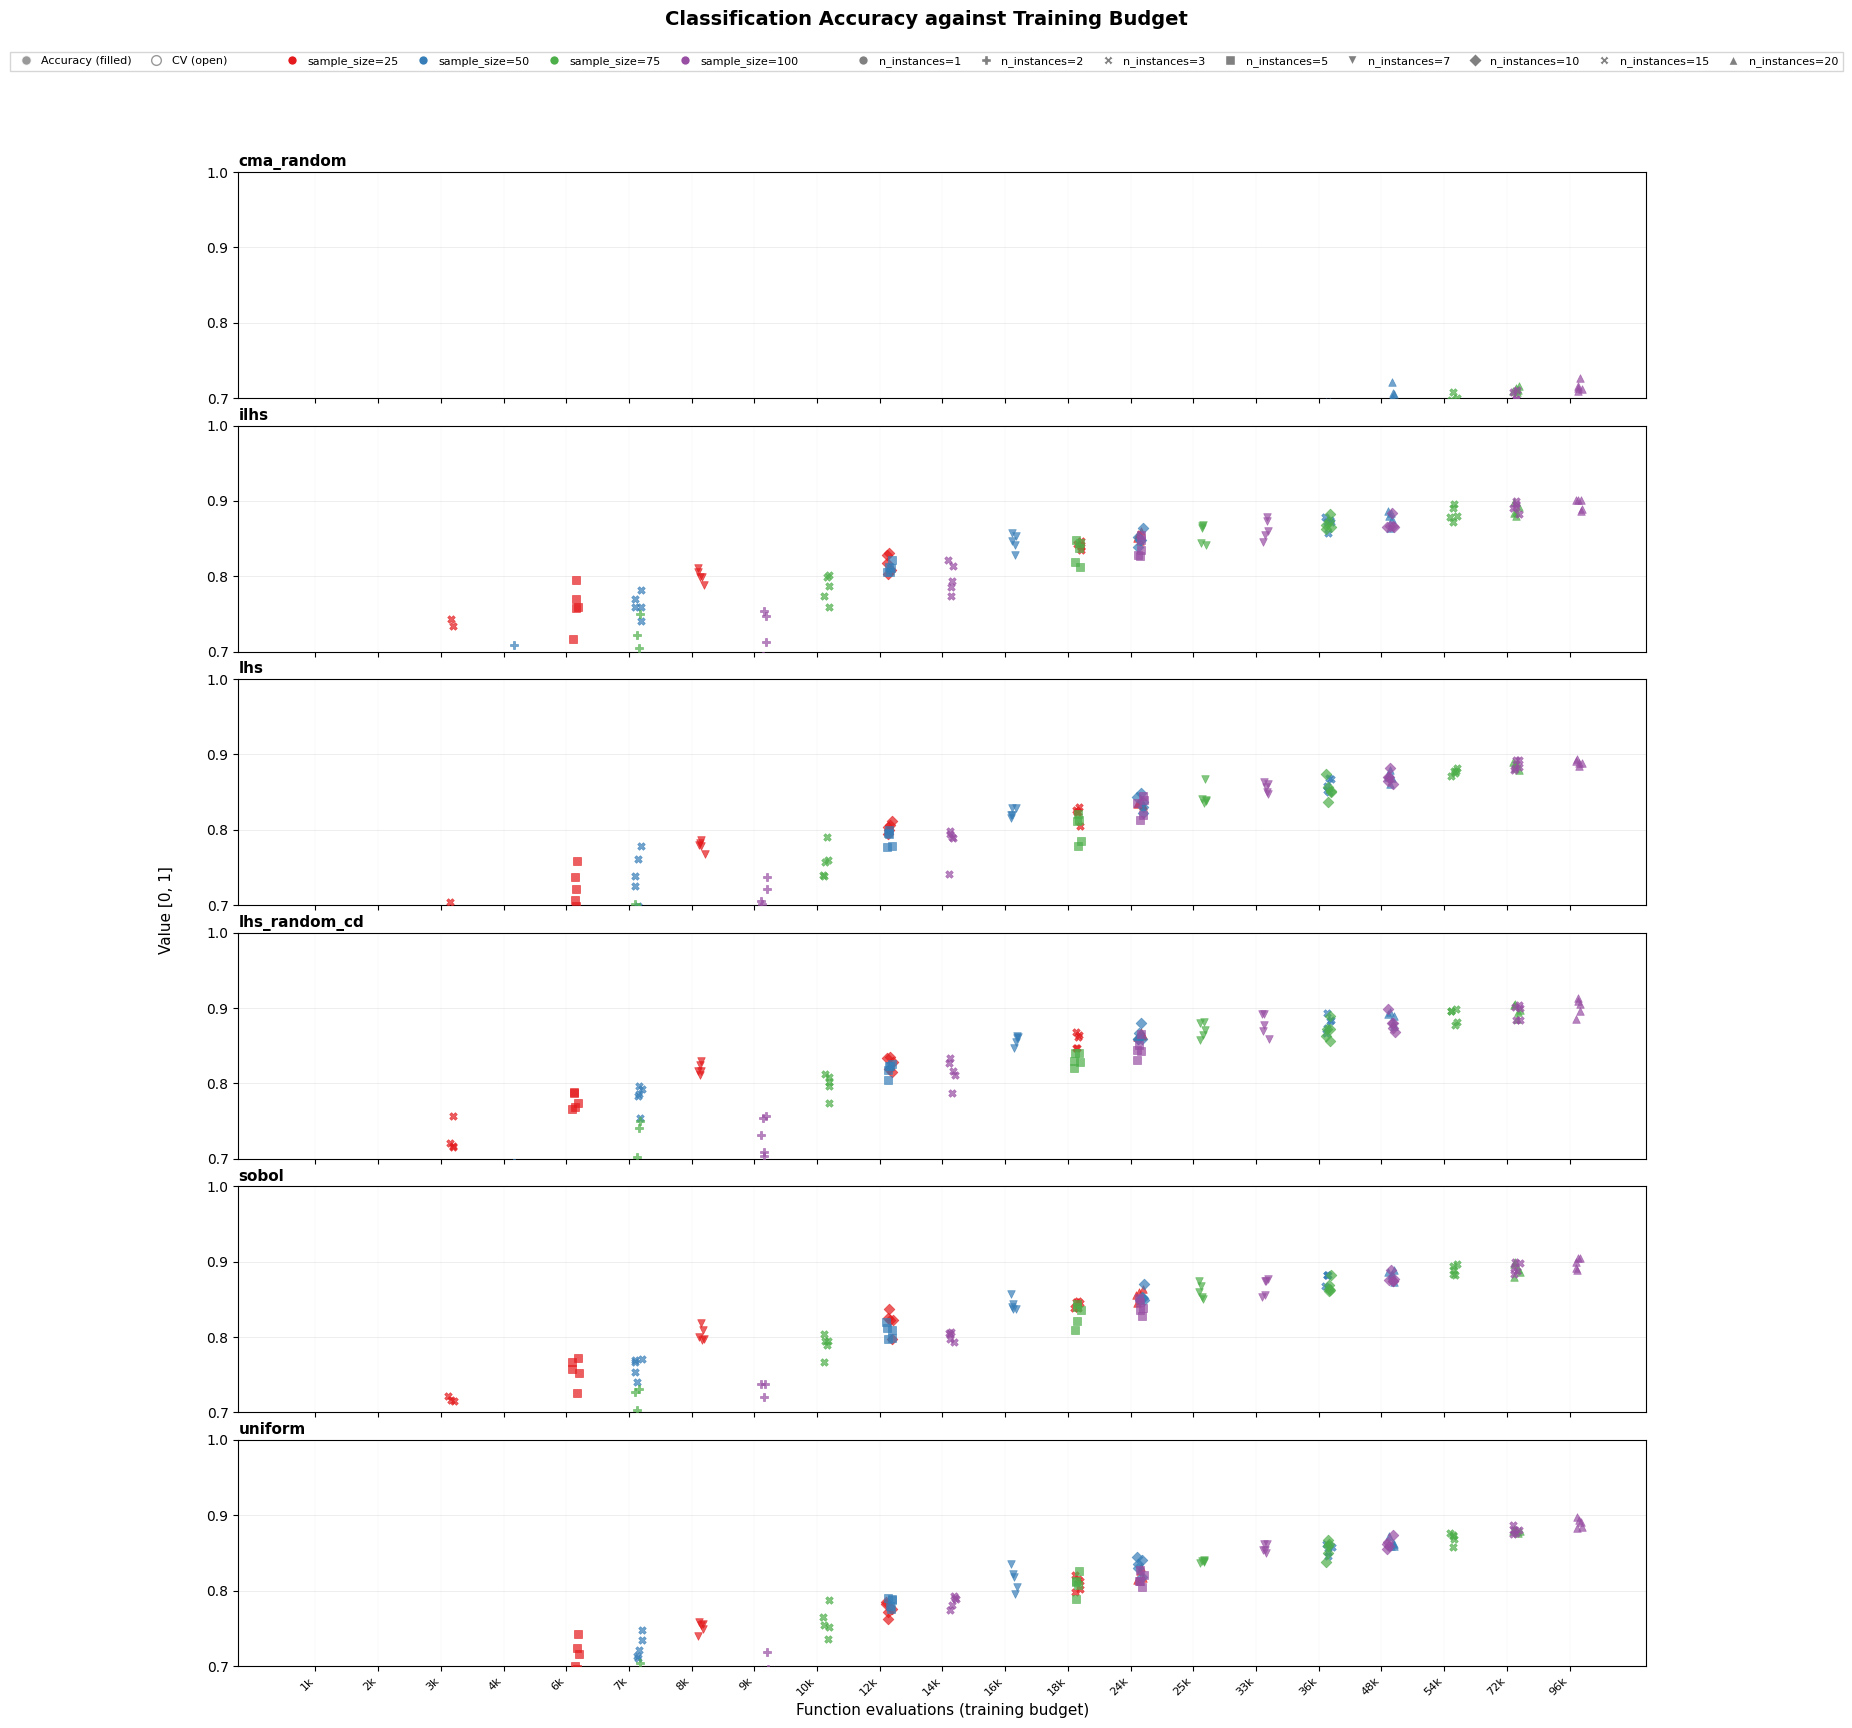

(<Figure size 1600x1800 with 6 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'lhs_random_cd'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [6]:
plot_cv_vs_accuracy(df[df.n_runs_train == 1], ylim=(0.7, 1.0))

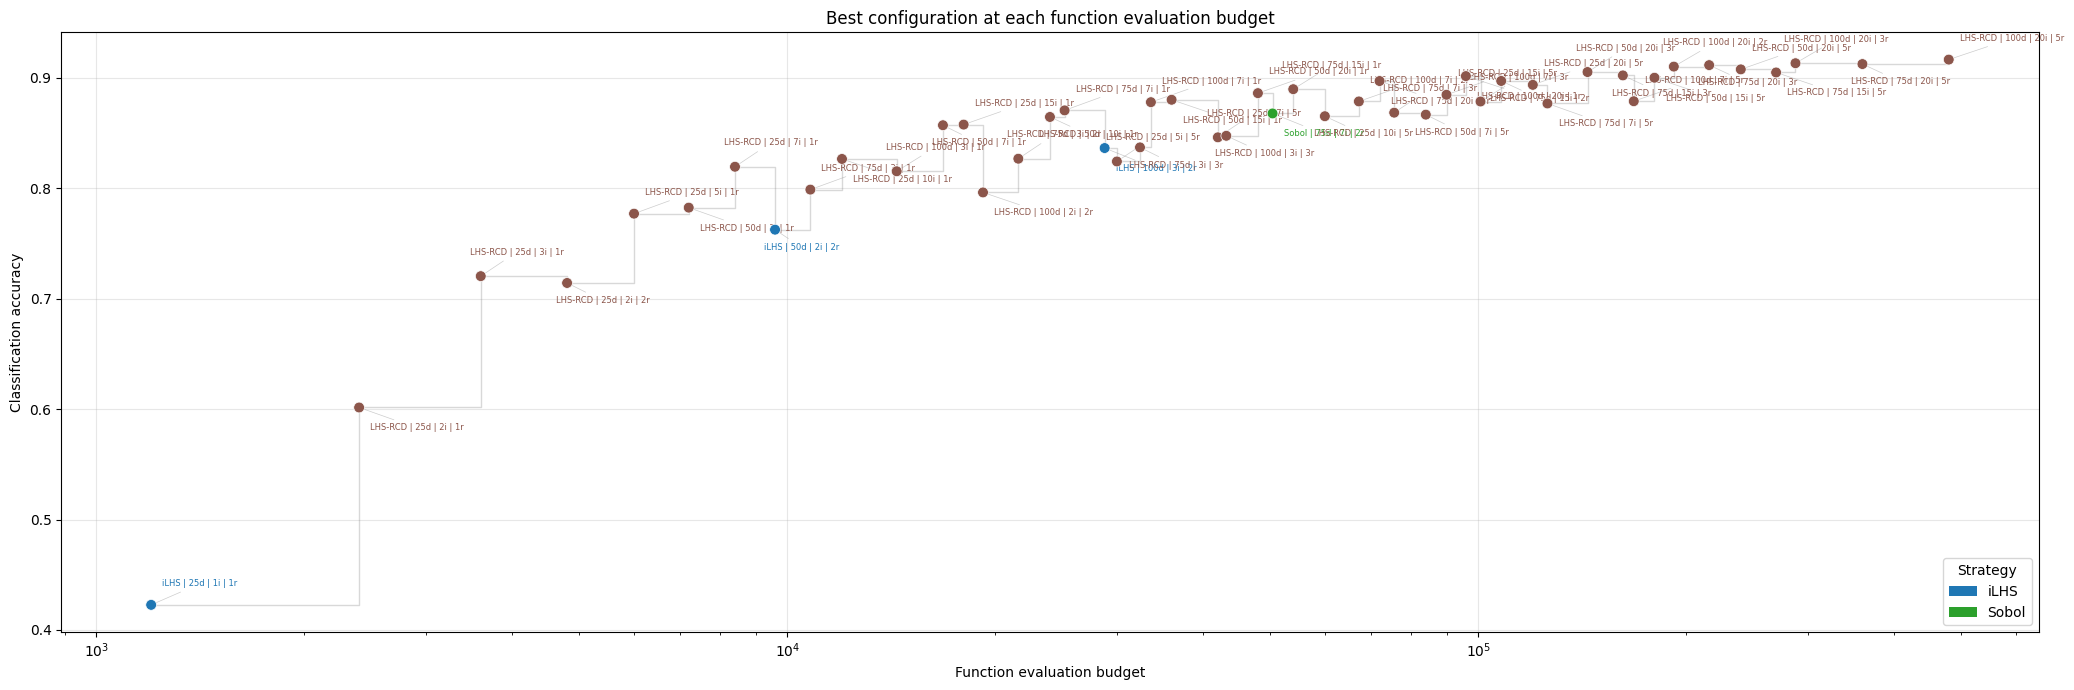

In [7]:
fig, best = plot_best_config_per_budget(
    fold_agg_df,
    target="acc_allruns_mean",
)
plt.show()

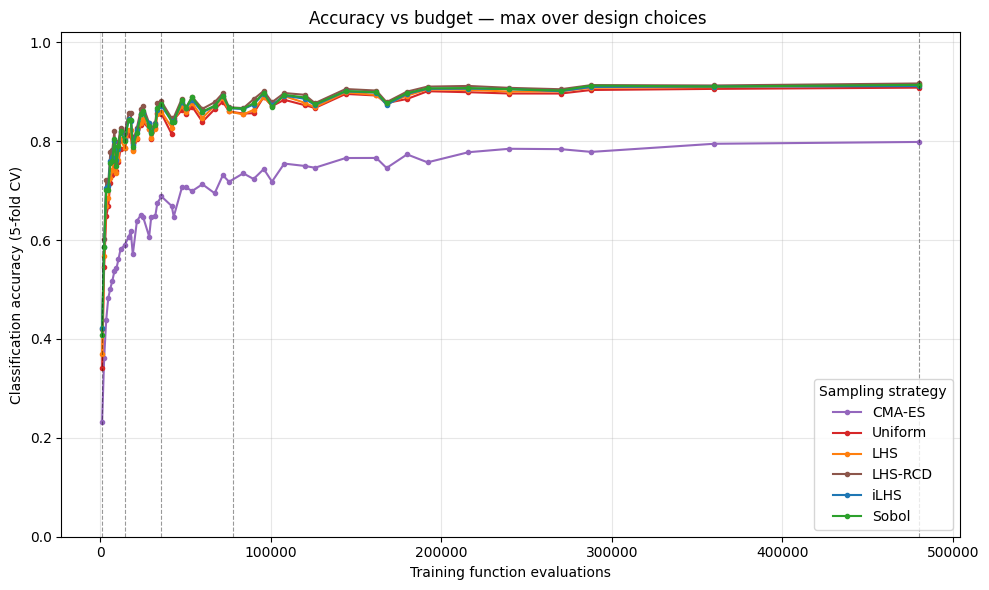

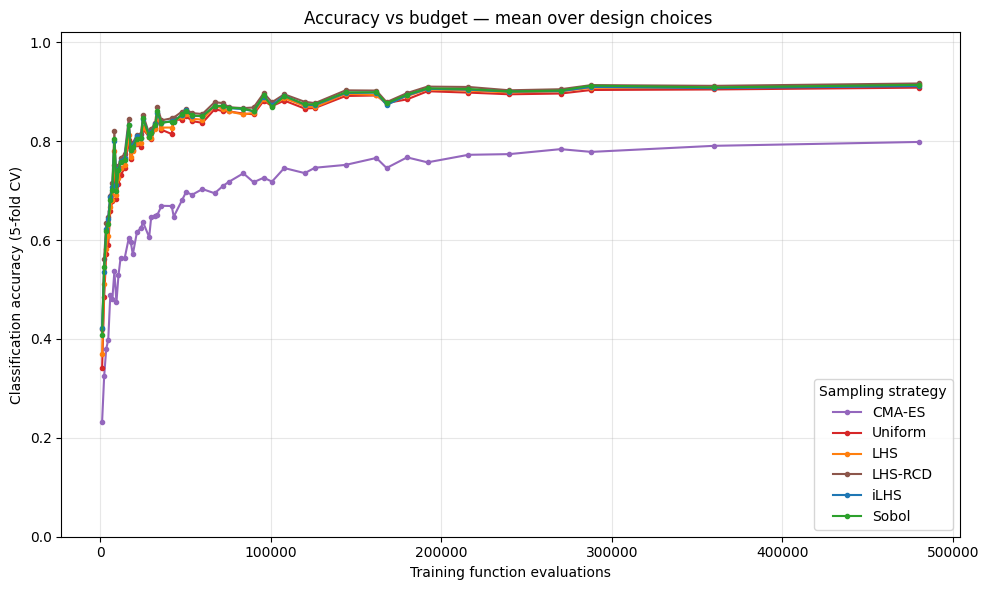

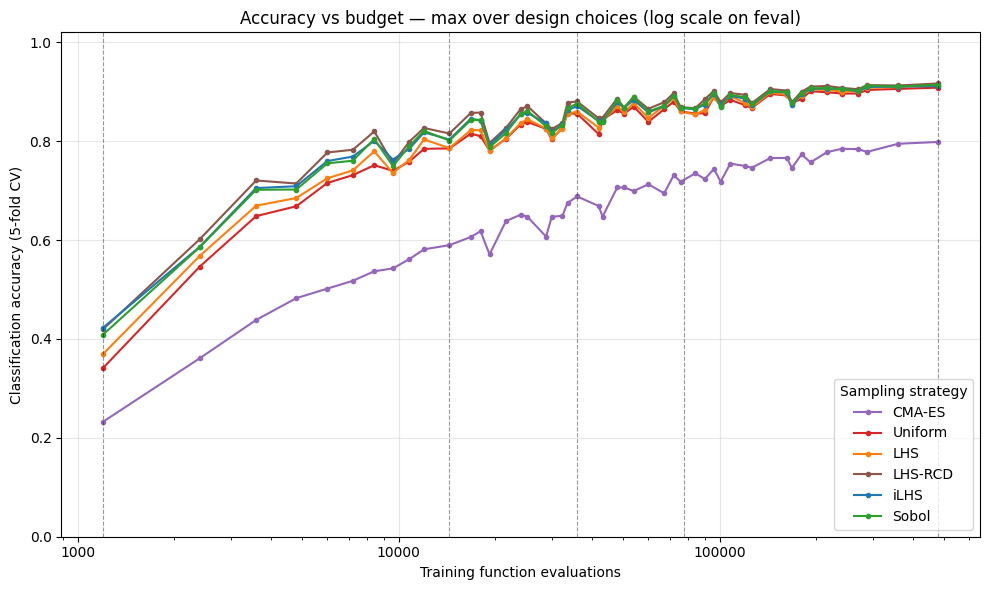

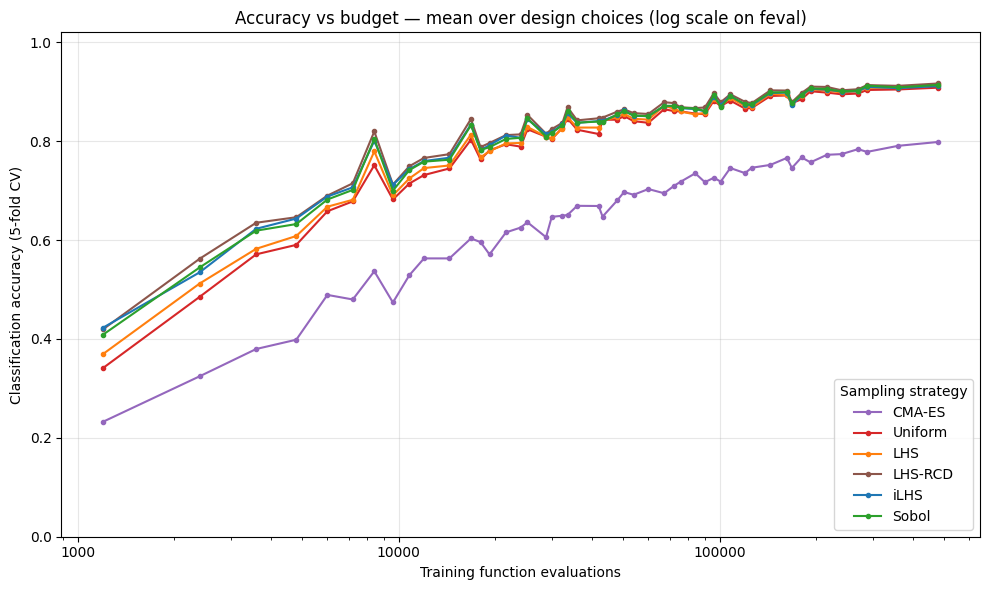

In [8]:
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean")
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4, log_scale=True)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean", log_scale=True)

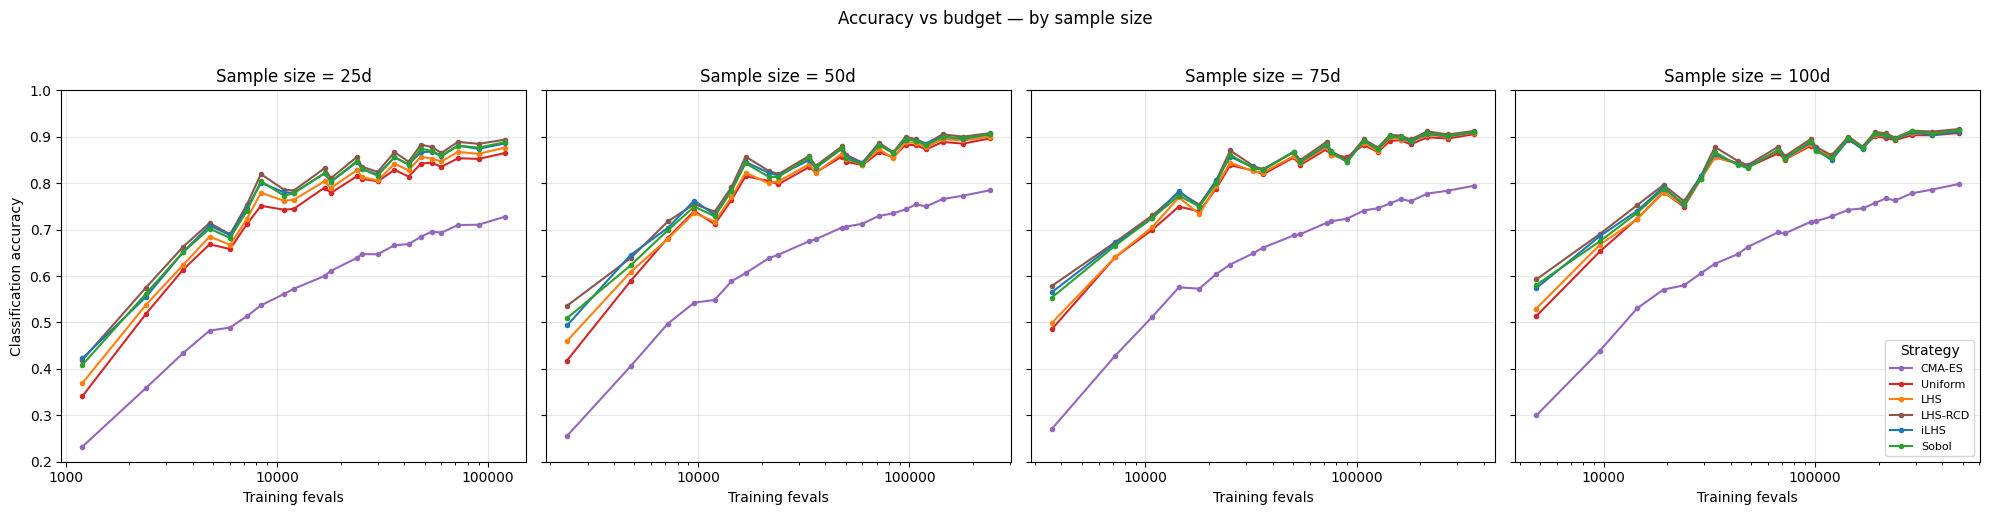

In [9]:
plot_accuracy_vs_budget_faceted(fold_agg_df, ylim = (0.2, 1.0))


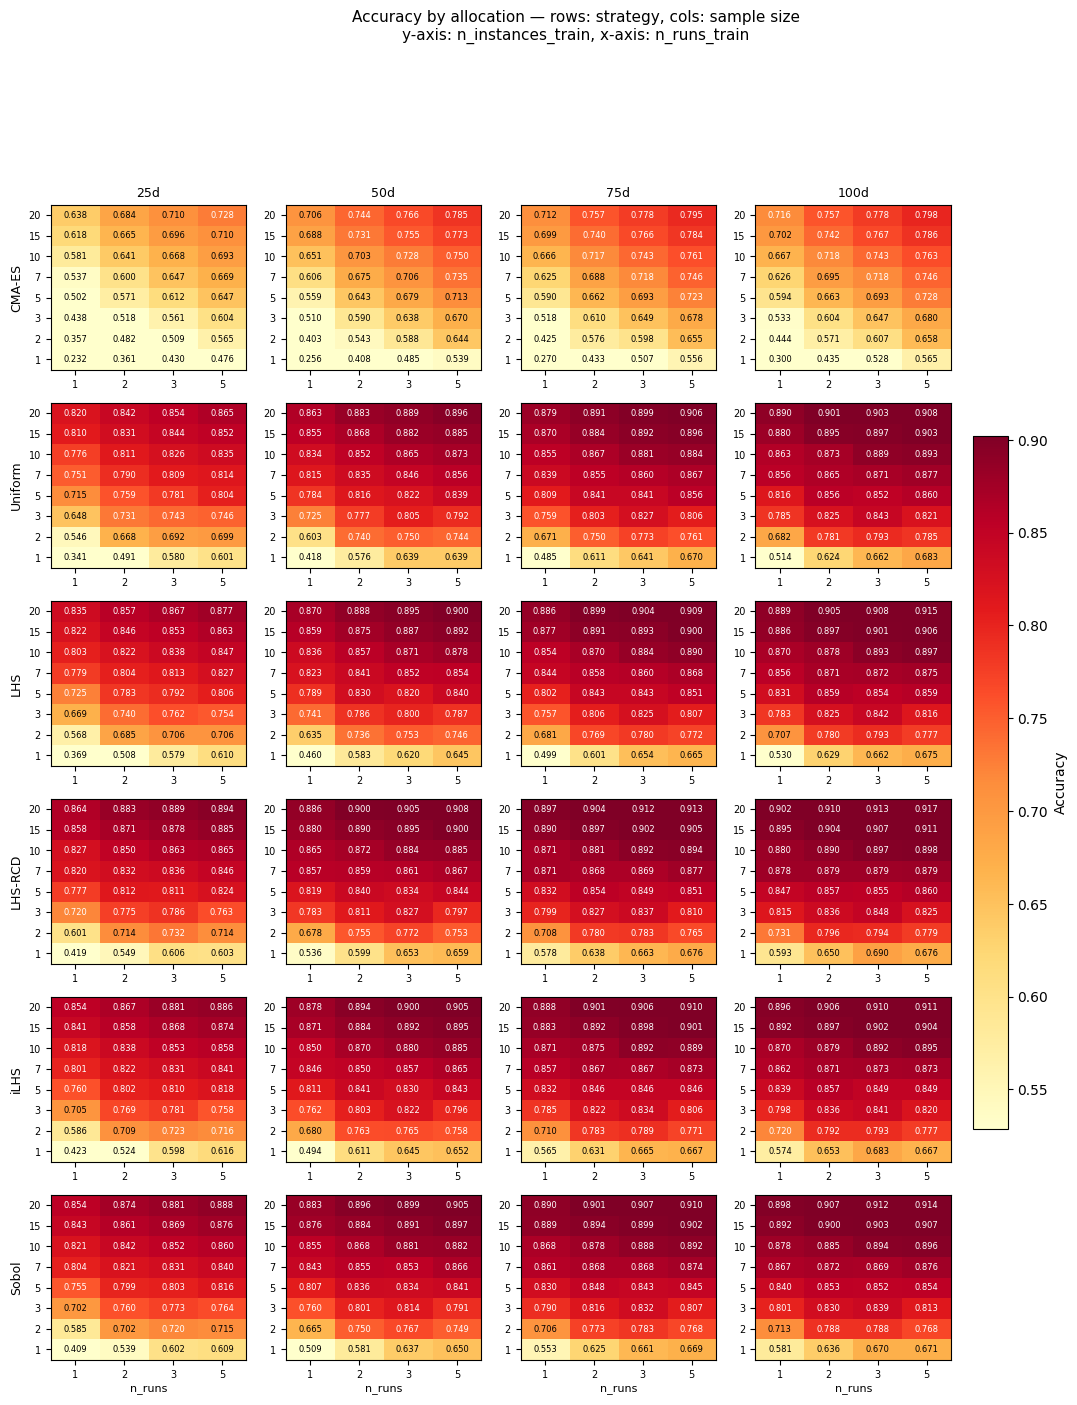

In [10]:
plot_allocation_heatmaps(fold_agg_df)


In [11]:
# from rq2_factor_importance import *
# imp_df = run_all(fold_agg_df, metric="acc_allruns_mean")

In [12]:
# from rq2_cv_accuracy import *
# run_all(fold_agg_df, cv_col="cv_instance_median_mean",
    #                                acc_col="acc_allruns_mean")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'lhs_random_cd', 'sobol', 'uniform']

Saturation curves for Strategy ...


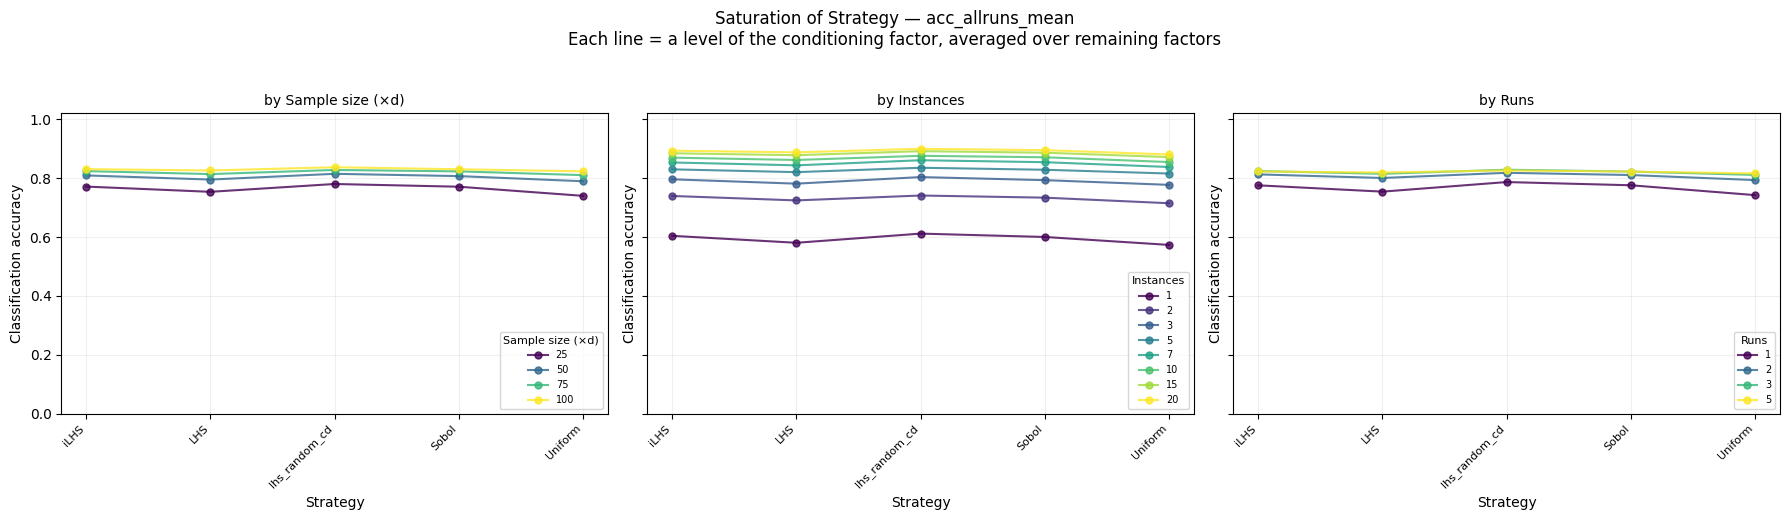

Saturation curves for Sample size (×d) ...


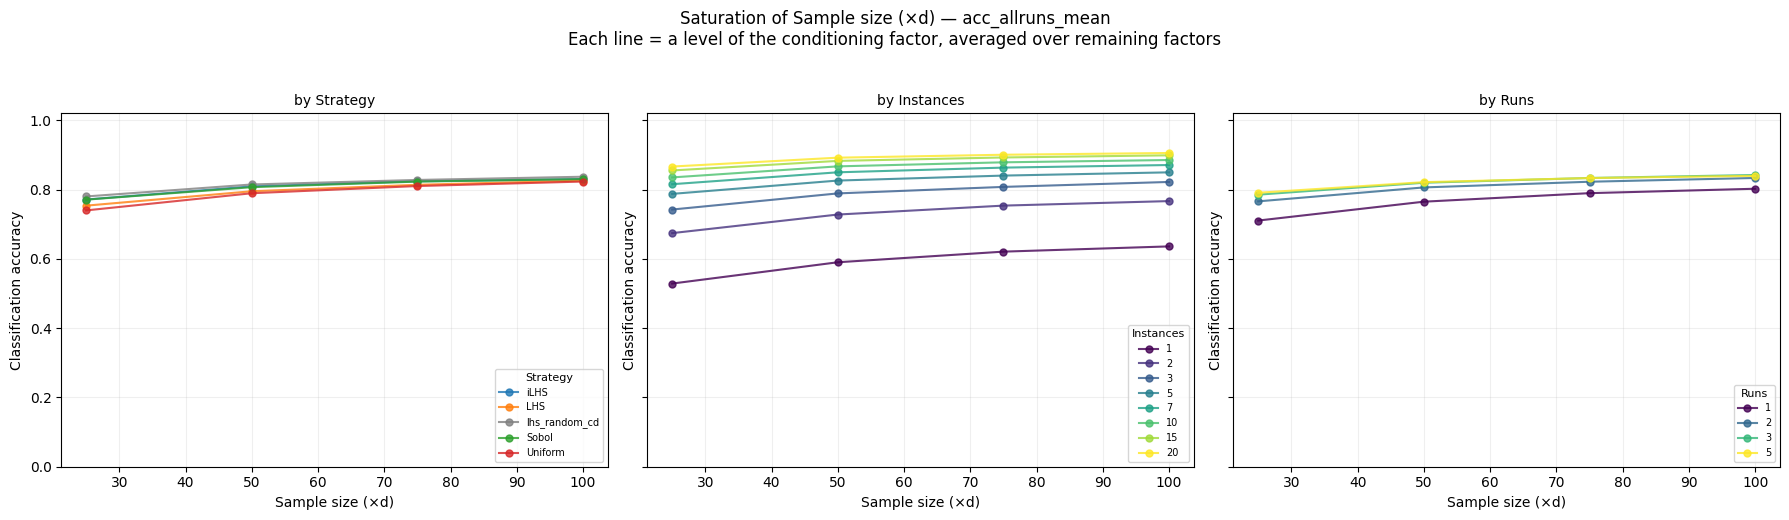

Saturation curves for Instances ...


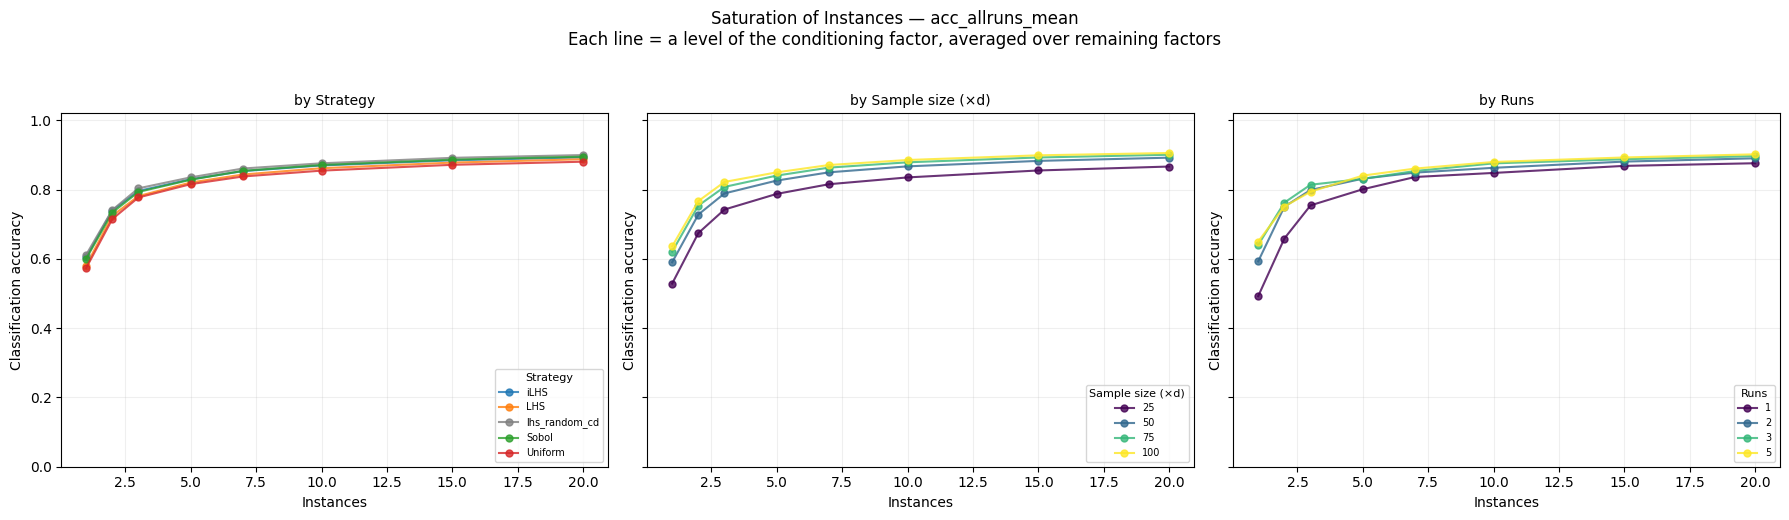

Saturation curves for Runs ...


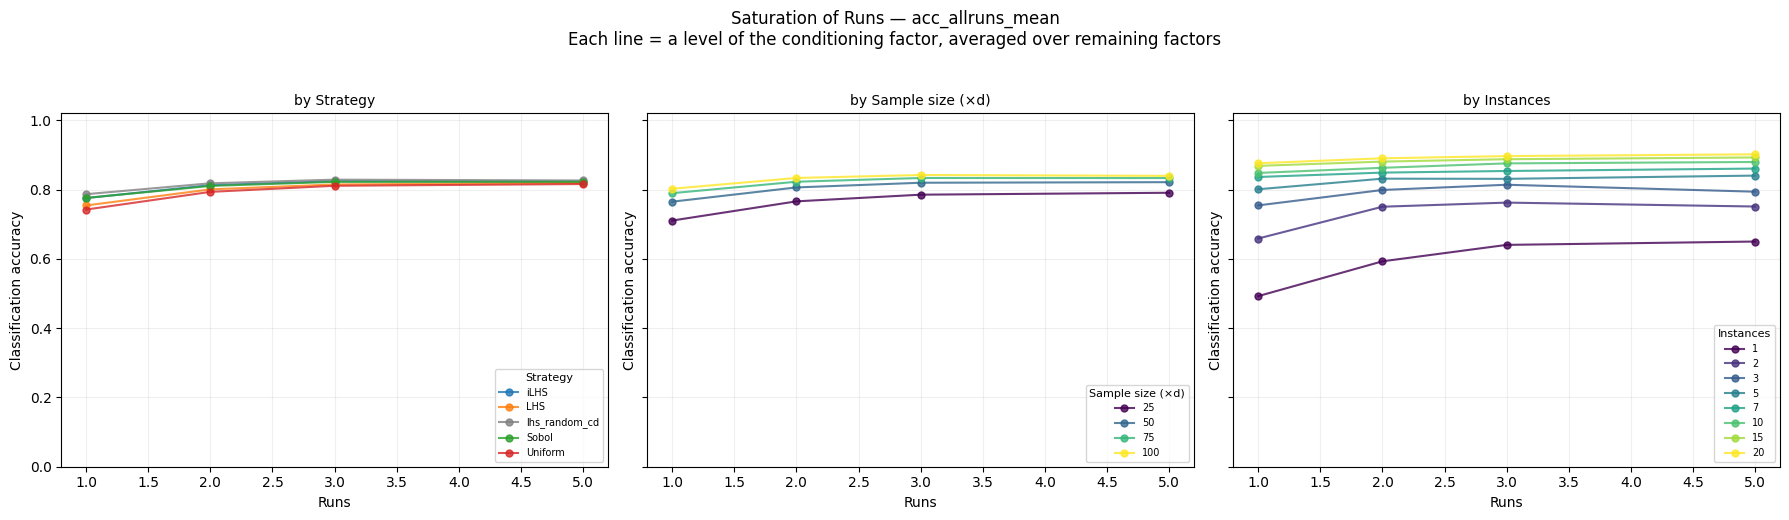

Marginal gains per step ...
          factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
Sample size (×d)          25        50   0.039943    0.066244          60.297139
Sample size (×d)          50        75   0.016643    0.066244          25.124258
Sample size (×d)          75       100   0.009657    0.066244          14.578602
       Instances           1         2   0.136766    0.297267          46.008008
       Instances           2         3   0.059588    0.297267          20.045145
       Instances           3         5   0.035675    0.297267          12.000993
       Instances           5         7   0.023983    0.297267           8.067718
       Instances           7        10   0.016619    0.297267           5.590664
       Instances          10        15   0.015839    0.297267           5.328291
       Instances          15        20   0.008797    0.297267           2.959180
            Runs           1         2   0.040178    0.054349          73.925399


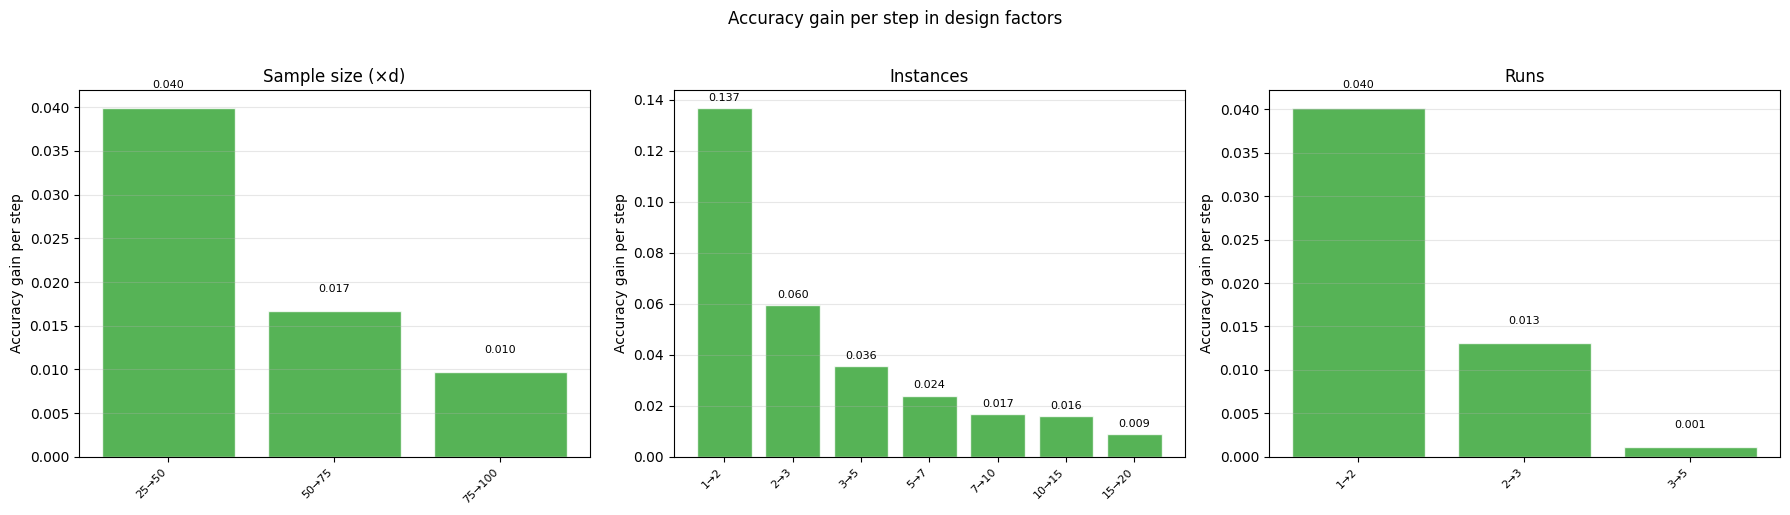

In [13]:
from rq2_saturation_curves import *

# All four factors + marginal gains table
gains_df = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'lhs_random_cd', 'sobol', 'uniform']

Overall saturation by tier: Strategy ...


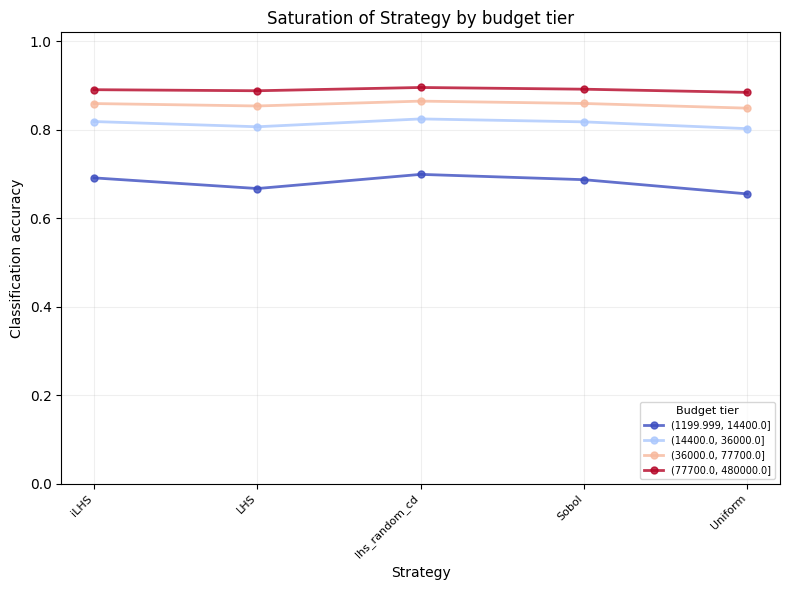

Overall saturation by tier: Sample size (×d) ...


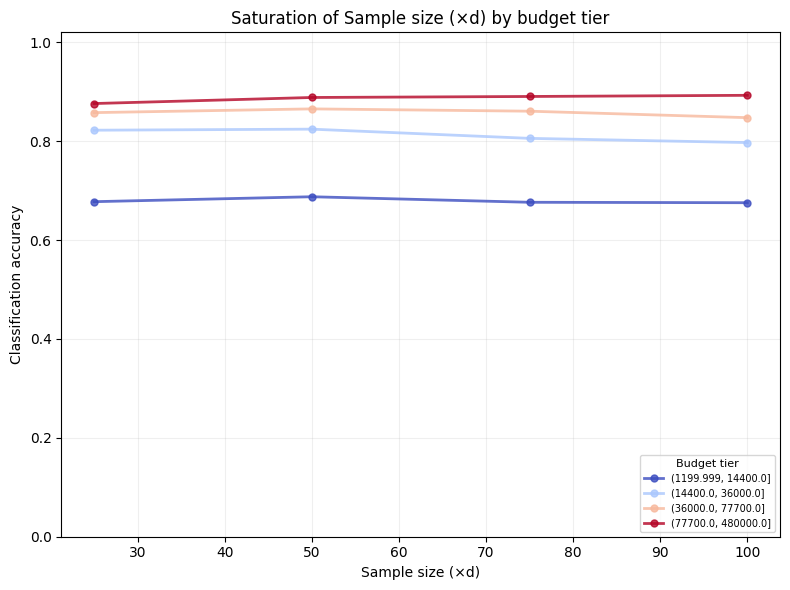

Overall saturation by tier: Instances ...


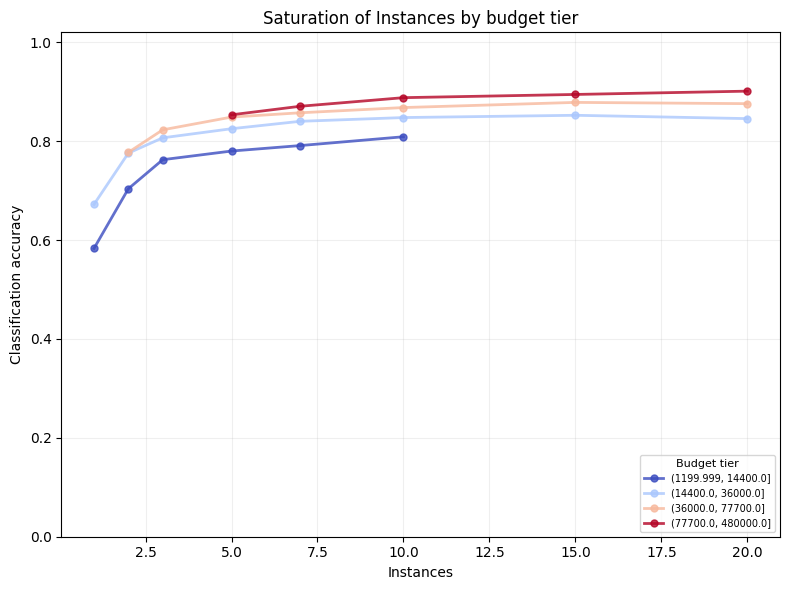

Overall saturation by tier: Runs ...


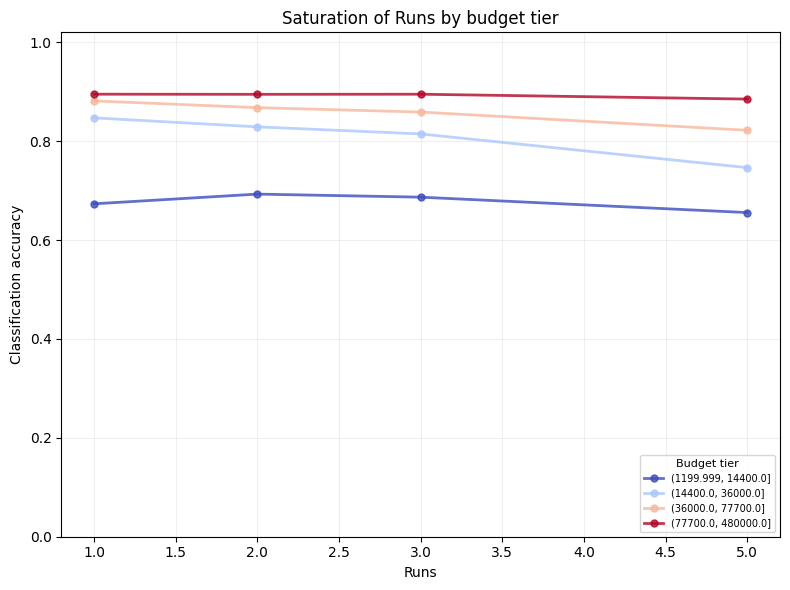

Per-tier saturation: Strategy ...


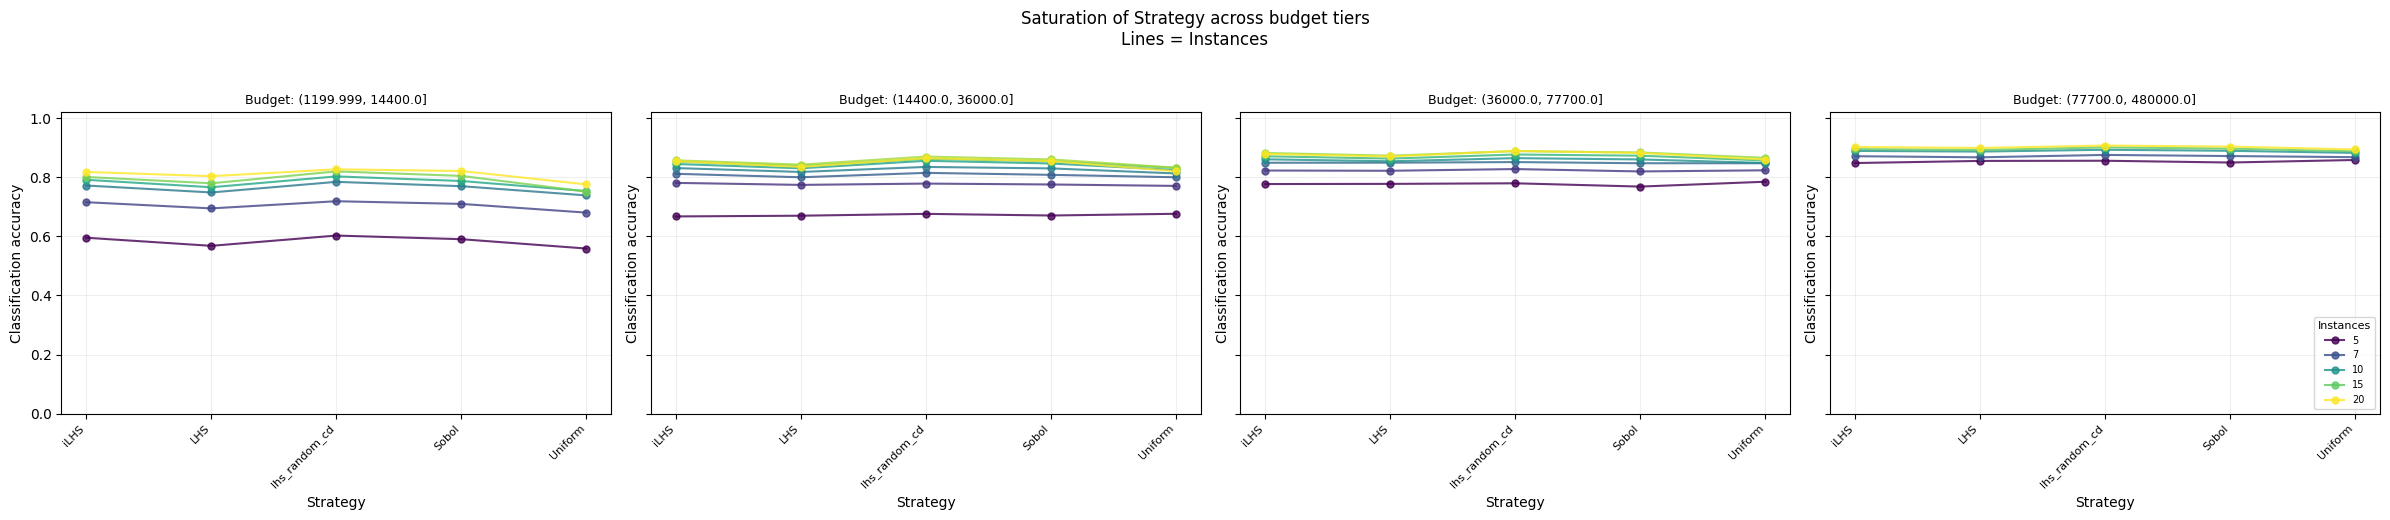

Per-tier saturation: Sample size (×d) ...


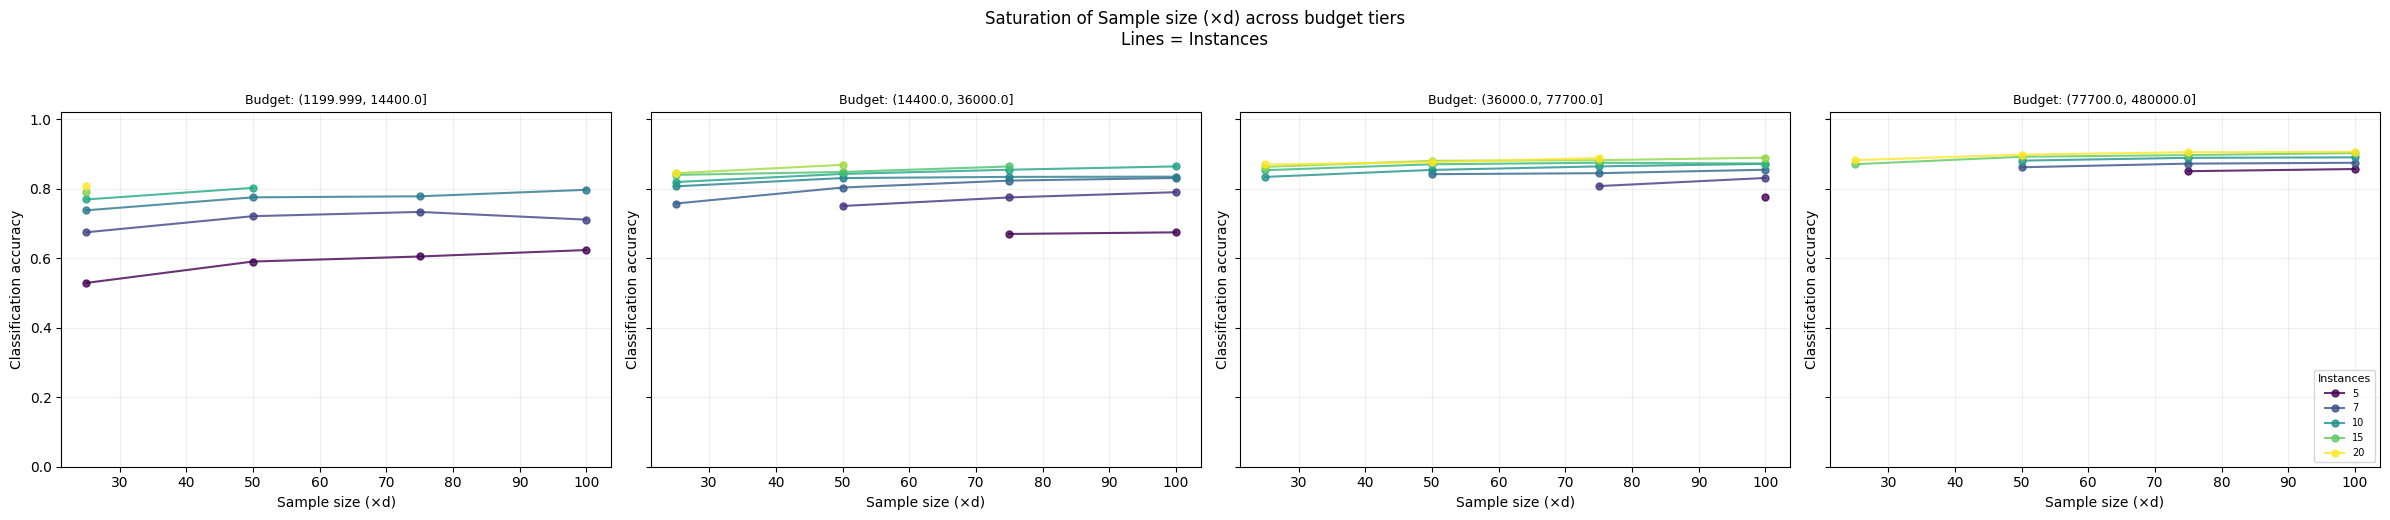

Per-tier saturation: Instances ...


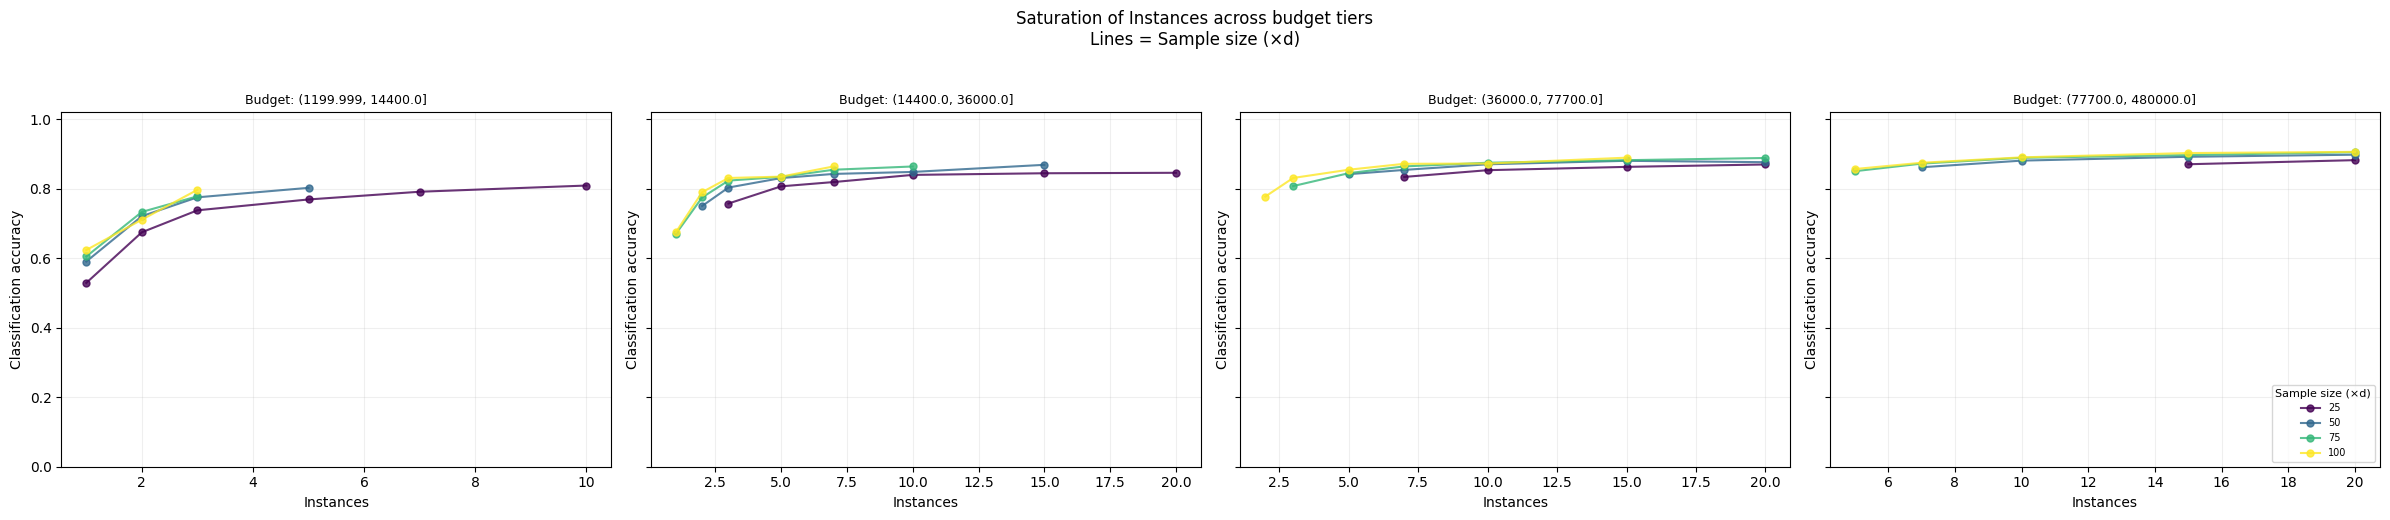

Per-tier saturation: Runs ...


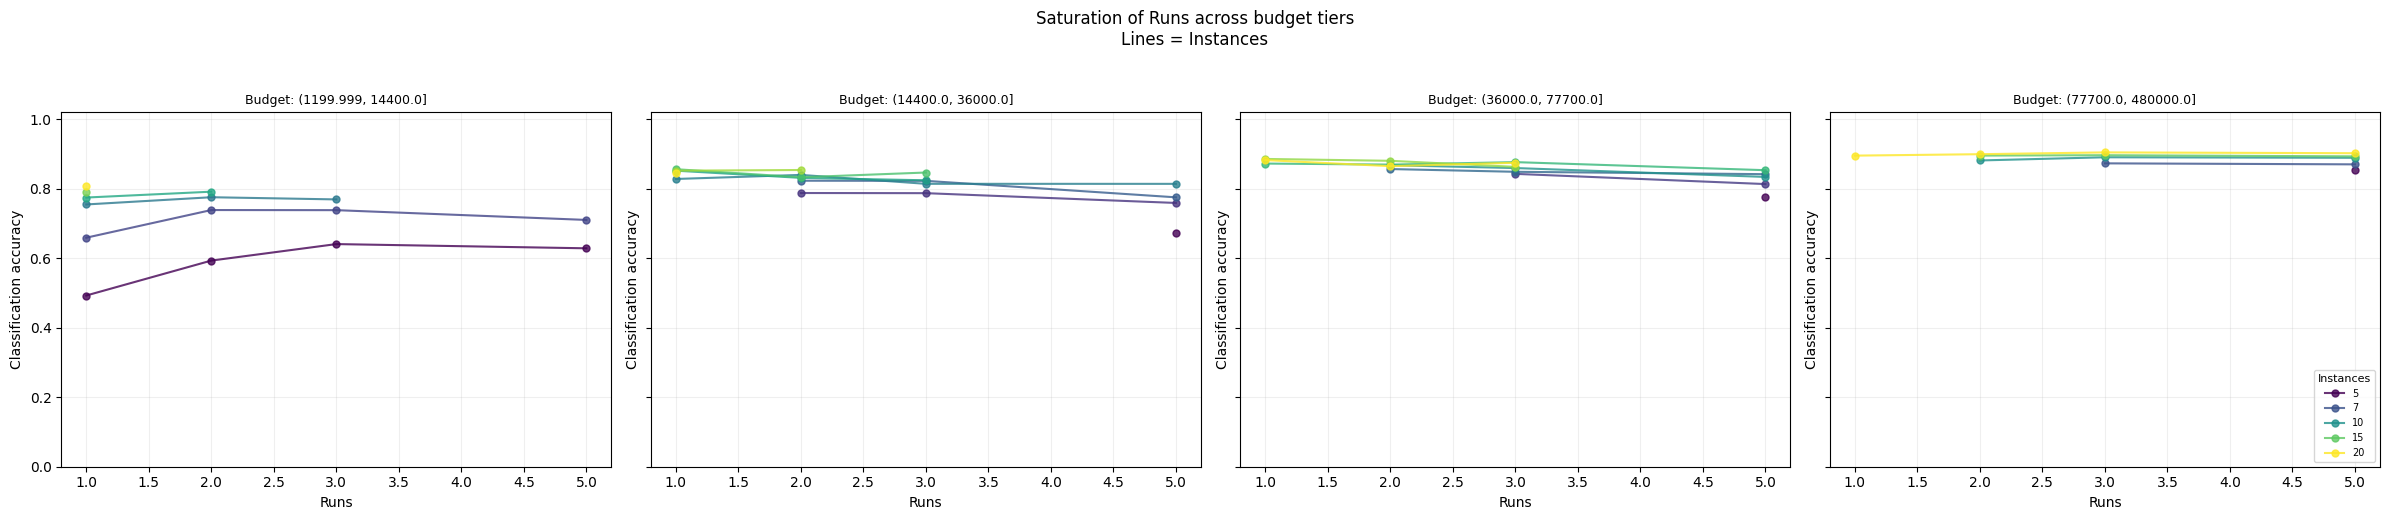

Marginal gains by tier ...
        budget_tier           factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
(1199.999, 14400.0] Sample size (×d)          25        50   0.009988   -0.002071        -482.185321
(1199.999, 14400.0] Sample size (×d)          50        75  -0.011194   -0.002071         540.407652
(1199.999, 14400.0] Sample size (×d)          75       100  -0.000865   -0.002071          41.777669
(1199.999, 14400.0]        Instances           1         2   0.120758    0.225956          53.443001
(1199.999, 14400.0]        Instances           2         3   0.058816    0.225956          26.029947
(1199.999, 14400.0]        Instances           3         5   0.017492    0.225956           7.741339
(1199.999, 14400.0]        Instances           5         7   0.011080    0.225956           4.903452
(1199.999, 14400.0]        Instances           7        10   0.017810    0.225956           7.882260
(1199.999, 14400.0]             Runs           1         2   0.0

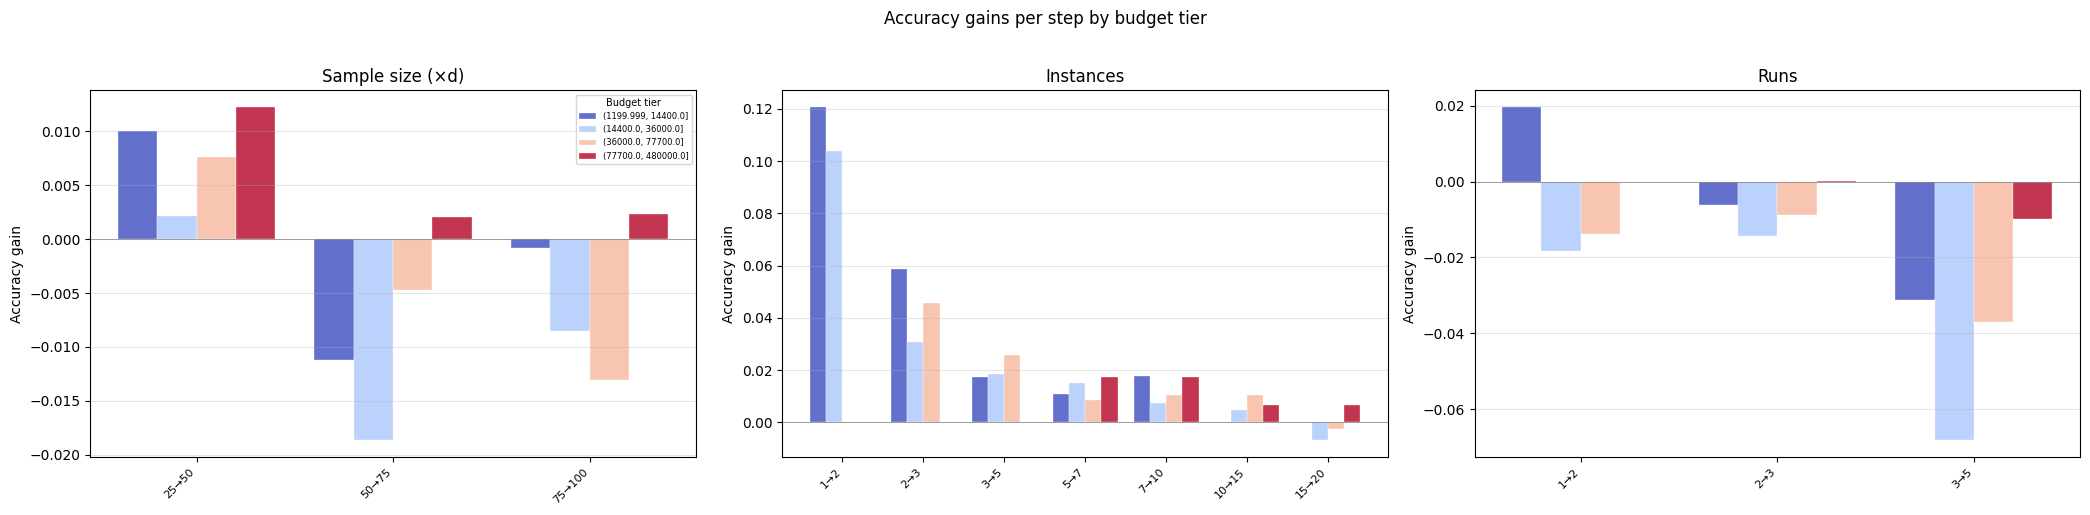

In [14]:
gains_by_tier = run_by_tier(fold_agg_df, metric="acc_allruns_mean",
                             omit_strategies="cma_random", n_tiers=4)

In [15]:
from rq2_fanova_stratified import *

df_d2 = fold_agg_df[fold_agg_df["dimension"] == 2][fold_agg_df["sampling_strategy"] != "cma_random"].copy()

results, summary, interactions = run_stratified_fanova(
    df_d2,
    hyperparams=["sample_size_per_dim", "sampling_strategy",
                 "n_instances_train", "n_runs_train"],
    target="acc_allruns_mean",
    budget_col="n_feval_train",
    n_budget_tiers=4,
)

In [16]:
results

,hyperparameter,importance_mean,importance_std,importance_raw,rank,rf_oob_r2,budget_tier,n_samples,budget_range_low,budget_range_high
0,n_instances_train,1.732578,0.081339,"[1.6895120008333868, 1.5623278711388013, 1.676...",1,NaN,ALL,640,1200.0,480000.0
1,n_runs_train,0.170919,0.015374,"[0.17407091806715136, 0.16734717781930053, 0.1...",2,NaN,ALL,640,1200.0,480000.0
2,sample_size_per_dim,0.145056,0.009325,"[0.13748294877765543, 0.14618432443396745, 0.1...",3,NaN,ALL,640,1200.0,480000.0
3,sampling_strategy,0.017653,0.001623,"[0.019339450283644477, 0.018432730951586374, 0...",4,NaN,ALL,640,1200.0,480000.0
4,n_instances_train,2.293920,0.168051,"[2.3038565747985995, 2.1502911876002364, 2.705...",1,NaN,Q1,180,1200.0,14400.0
5,n_runs_train,0.544661,0.056341,"[0.49339123536264873, 0.5621014295382305, 0.44...",2,NaN,Q1,180,1200.0,14400.0
6,sample_size_per_dim,0.305762,0.026858,"[0.27198075846109016, 0.3017904092705077, 0.32...",3,NaN,Q1,180,1200.0,14400.0
7,sampling_strategy,0.047313,0.004601,"[0.05379749788514898, 0.04744437707045768, 0.0...",4,NaN,Q1,180,1200.0,14400.0
8,n_instances_train,1.544097,0.114115,"[1.4193366293064589, 1.5486983889782127, 1.501...",1,NaN,Q2,170,14400.0,36000.0
9,sample_size_per_dim,0.122946,0.012308,"[0.12137492554290785, 0.11678413414678013, 0.1...",2,NaN,Q2,170,14400.0,36000.0


In [17]:
summary

hyperparameter,n_instances_train,n_runs_train,sample_size_per_dim,sampling_strategy
budget_tier,,,,
ALL,1.732578,0.170919,0.145056,0.017653
Q1,2.293920,0.544661,0.305762,0.047313
Q2,1.544097,0.101755,0.122946,0.070997
Q3,0.921645,0.343656,0.081877,0.121751
Q4,1.848501,0.108037,0.437942,0.113091


In [18]:
interactions

,pair,hp_i,hp_j,joint_importance_mean,joint_importance_std,individual_sum,interaction_strength,budget_tier
0,n_instances_train × n_runs_train,n_instances_train,n_runs_train,1.865837,0.063699,1.903497,-0.037659,ALL
1,sampling_strategy × n_instances_train,sampling_strategy,n_instances_train,1.782490,0.066486,1.750231,0.032259,ALL
2,sample_size_per_dim × n_instances_train,sample_size_per_dim,n_instances_train,1.903843,0.068548,1.877635,0.026208,ALL
3,sample_size_per_dim × n_runs_train,sample_size_per_dim,n_runs_train,0.302976,0.026443,0.315975,-0.012999,ALL
4,sampling_strategy × n_runs_train,sampling_strategy,n_runs_train,0.185580,0.017765,0.188572,-0.002992,ALL
5,sample_size_per_dim × sampling_strategy,sample_size_per_dim,sampling_strategy,0.160121,0.008733,0.162709,-0.002588,ALL
6,n_instances_train × n_runs_train,n_instances_train,n_runs_train,2.068451,0.189242,2.838581,-0.770131,Q1
7,sample_size_per_dim × n_instances_train,sample_size_per_dim,n_instances_train,2.150072,0.186347,2.599683,-0.449611,Q1
8,sample_size_per_dim × n_runs_train,sample_size_per_dim,n_runs_train,0.758119,0.060361,0.850424,-0.092305,Q1
9,sampling_strategy × n_instances_train,sampling_strategy,n_instances_train,2.295525,0.215628,2.341234,-0.045709,Q1


In [19]:
from rq2_rf_impurity_importance import *
df_d2 = fold_agg_df[fold_agg_df["dimension"] == 2][fold_agg_df["sampling_strategy"] != "cma_random"].copy()
results_imp, summary_imp, metrics_df = run_stratified_impurity_importance(
    df_d2,
    hyperparams=["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
    target="acc_allruns_mean",
    budget_col="n_feval_train",
    n_budget_tiers=4,
)

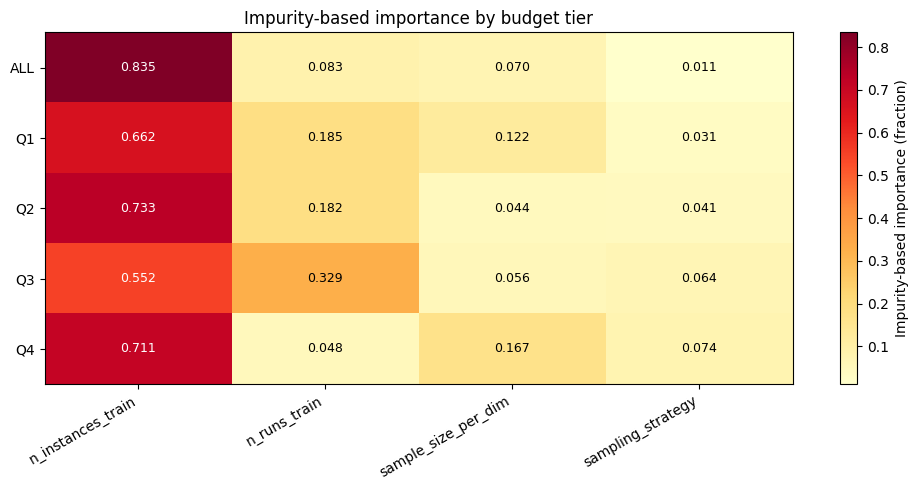

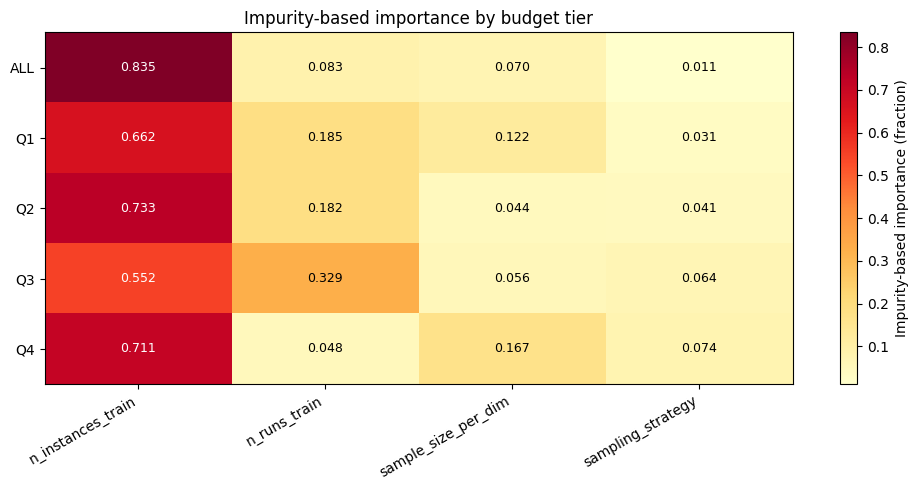

In [20]:
plot_importance_heatmap(summary_imp)


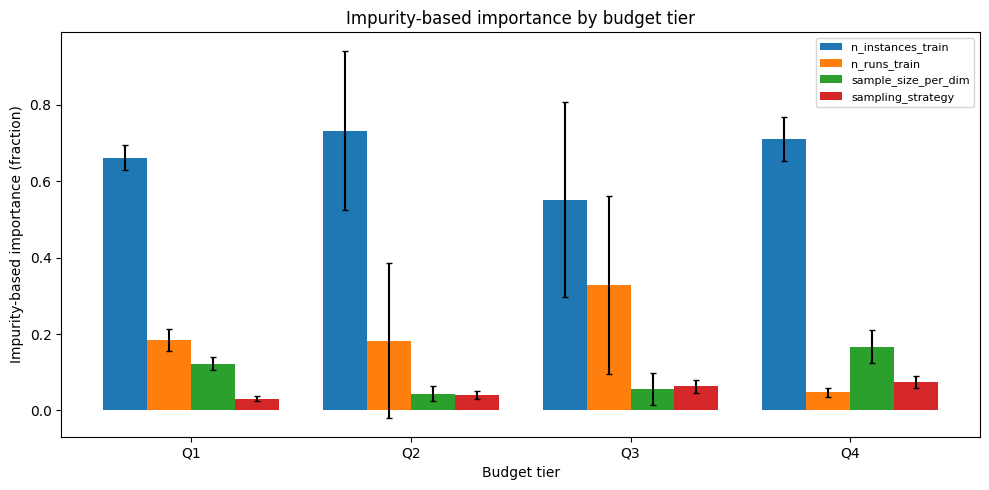

In [21]:
plot_importance_bars(results_imp)
plt.show()


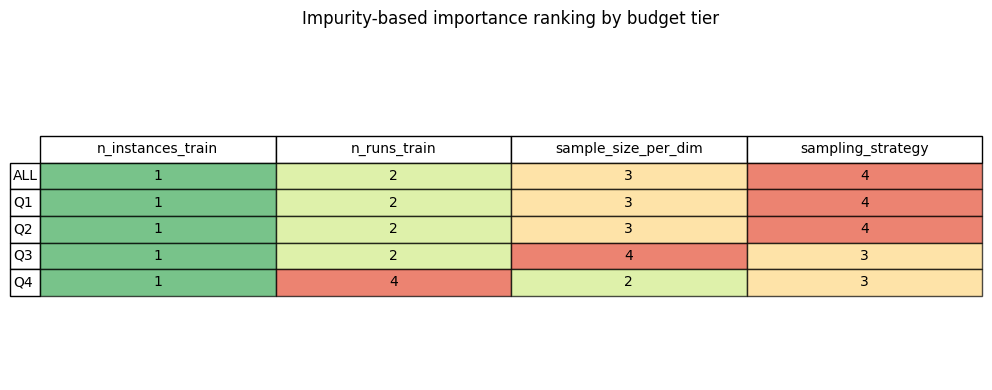

In [22]:
plot_rank_table(results_imp)
plt.show()

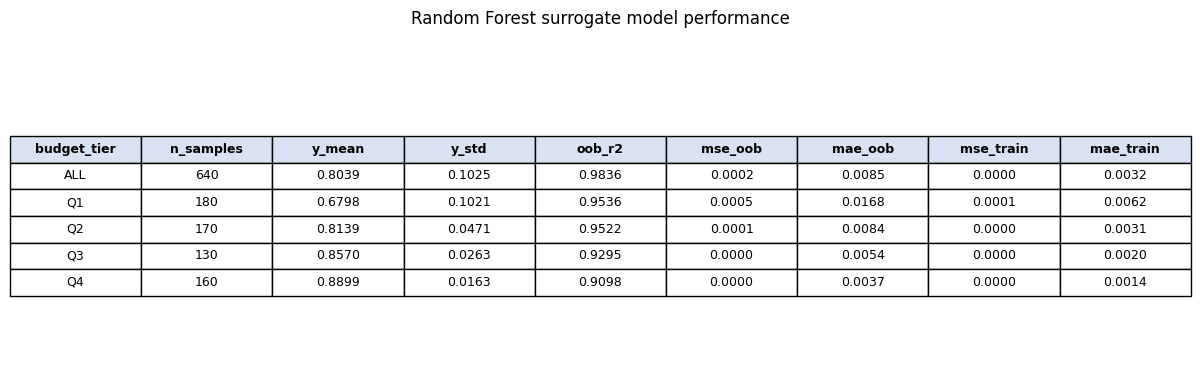

In [23]:
plot_metrics_table(metrics_df)
plt.show()


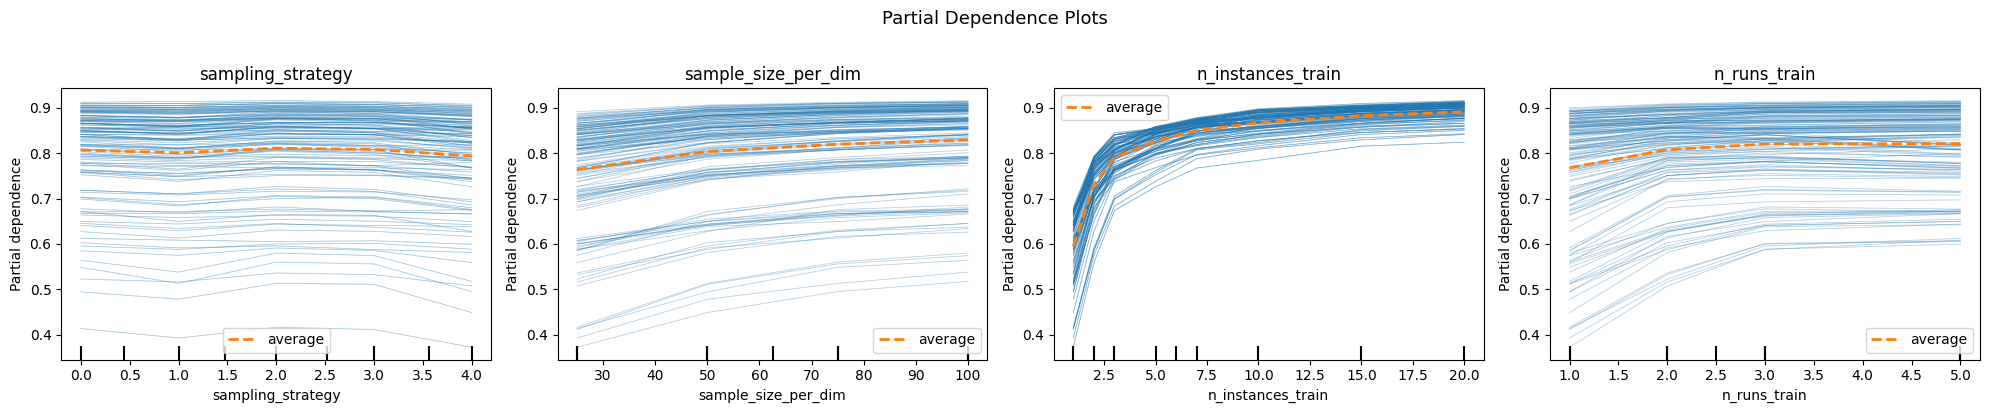

In [24]:
plot_pdp_individual(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], target="acc_allruns_mean")
plt.show()


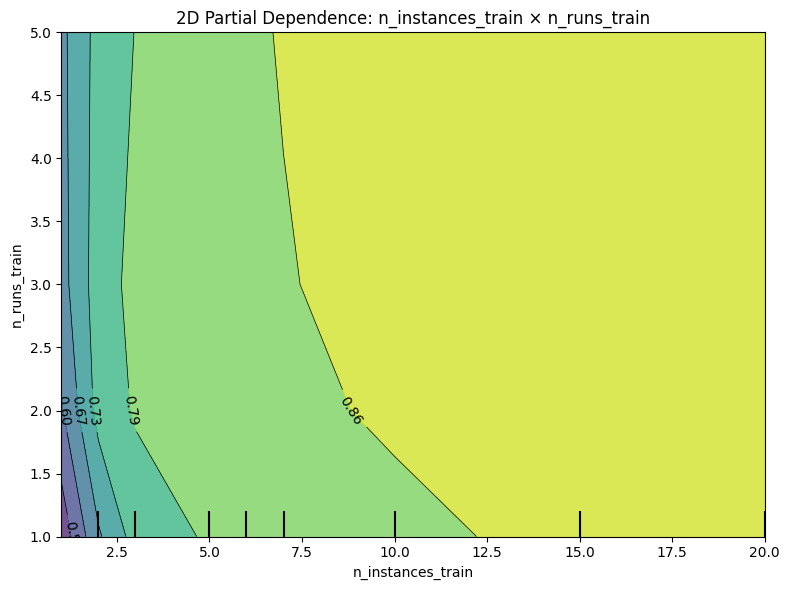

In [25]:
plot_pdp_2d(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"),
            target="acc_allruns_mean")
plt.show()

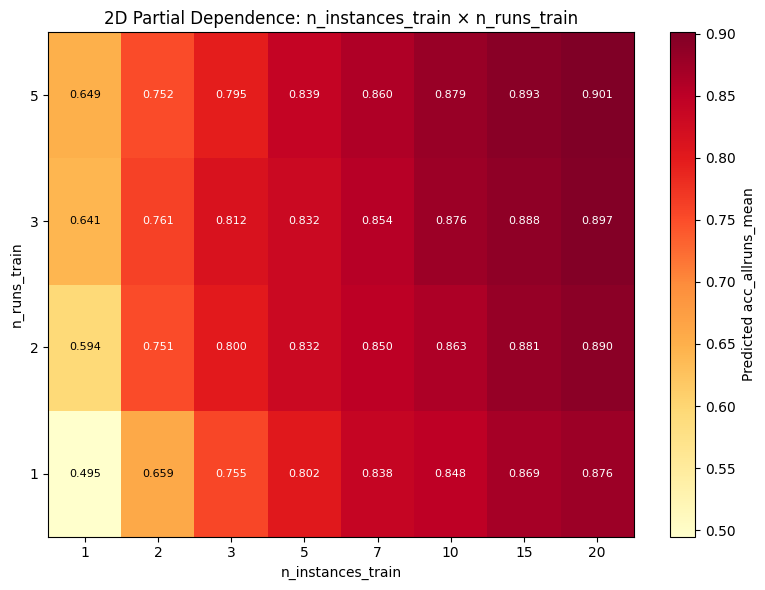

In [26]:
plot_pdp_2d_heatmap(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"),
            target="acc_allruns_mean",
            annotate=True)
plt.show()

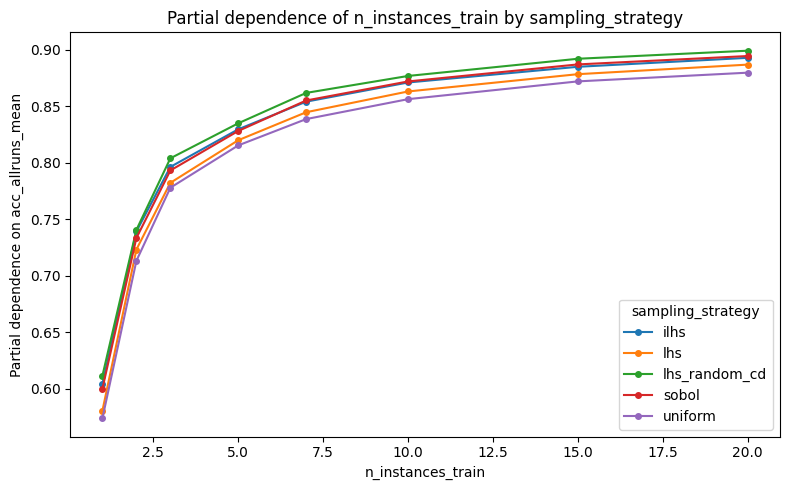

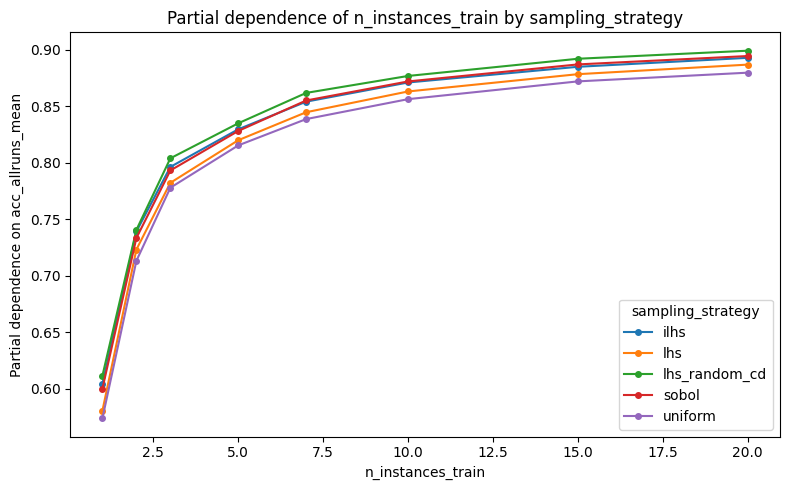

In [27]:
plot_pdp_by_strategy(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_instances_train")


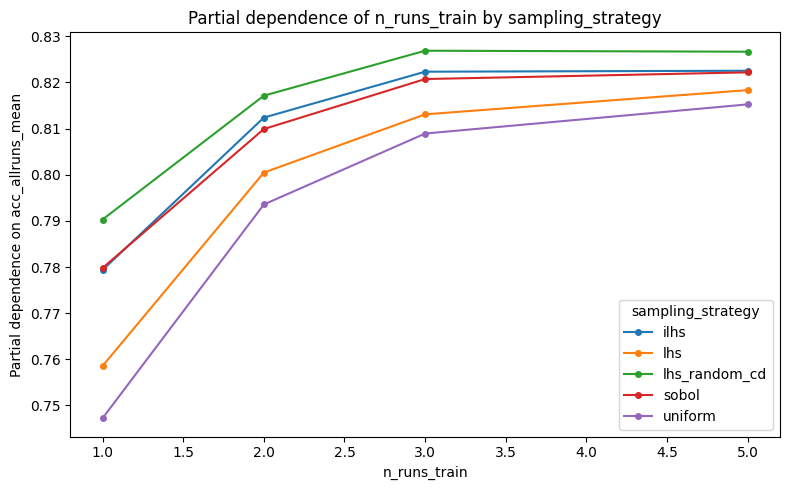

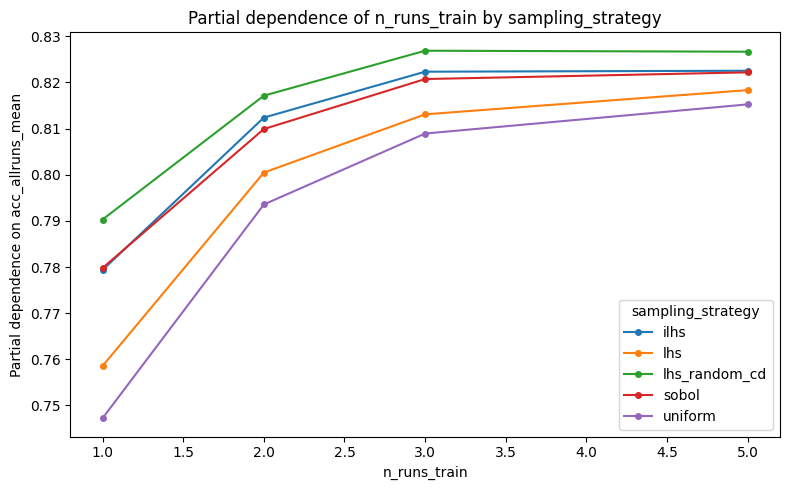

In [28]:
plot_pdp_by_strategy(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_runs_train")